# Домашнее задание: Урок 12 Подготовка к ML

**Курс:** Машинное обучение для начинающих, Неделя 6

---

## Задача

Продолжить работу с ВАШИМ датасетом из Урока 11 и подготовить его для машинного обучения:
1. Закодировать категориальные признаки
2. Масштабировать числовые признаки
3. Выбрать важные признаки
4. Разделить на Train/Test

---

## Важно!

- Работаете с ВАШИМ чистым датасетом из Урока 11 (название_clean.csv)
- В каждой части **обязательно пишите анализ** что вы сделали и почему
- Не все методы подойдут к вашему датасету — объясните почему
- Если у вас нет категориальных признаков — напишите это и пропустите кодирование

---

## Часть 1: Загрузка данных

Загрузите ваш чистый датасет из Урока 11.

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ВАШ КОД ЗДЕСЬ
# Загрузите датасет
# df = pd.read_csv('ваш_датасет_clean.csv')

df = pd.read_csv('games_sales_clean.csv')

In [ ]:
# Проверка данных
# ВАШ КОД ЗДЕСЬ
# df.head()
# df.info()


df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16291 entries, 0 to 16290
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Platform      16291 non-null  object 
 1   Year          16291 non-null  float64
 2   Genre         16291 non-null  object 
 3   Publisher     16291 non-null  object 
 4   NA_Sales      16291 non-null  float64
 5   EU_Sales      16291 non-null  float64
 6   JP_Sales      16291 non-null  float64
 7   Other_Sales   16291 non-null  float64
 8   Global_Sales  16291 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.1+ MB


### Ваш анализ:

**Напишите здесь:**
- Откуда датасет: Kaggle
- Сколько строк и колонок: 16 291 строка и 9 колонок
- Какие есть числовые колонки: Year, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales.
- Какие есть категориальные колонки: Platform, Genre, Publisher
- Что является целевой переменной (target): Global_Sales

---

## Часть 2: Кодирование категориальных признаков

Если у вас есть категориальные признаки закодируйте их.

**Методы:**
- Label Encoding - для бинарных/порядковых
- One-Hot Encoding - для номинальных (без порядка)

**Если категориальных нет** - напишите "Категориальных признаков нет" и переходите к Части 3.

In [ ]:
# ВАШ КОД ЗДЕСЬ

# Пример Label Encoding:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df['колонка'] = le.fit_transform(df['колонка'])

# Пример One-Hot Encoding:
# df = pd.get_dummies(df, columns=['колонка1', 'колонка2'], drop_first=True)

df = pd.get_dummies(df, columns=['Platform', 'Genre'], drop_first=True)






KeyError: "['Platform', 'Genre'] not in index"

### Ваш анализ:

**Напишите здесь:**
- Какие колонки закодировали: Platform, Genre
- Какой метод использовали для каждой и почему: One-Hot Encoding категориальных данных для облегчения обучения.
- Сколько новых колонок появилось: 41

---

## Часть 3: Масштабирование числовых признаков

Примените масштабирование к числовым признакам.

**Методы:**
- **Normalization (MinMaxScaler)** - если нет выбросов, диапазон [0, 1]
- **Standardization (StandardScaler)** - если есть выбросы, mean=0, std=1

**Выберите один** метод и объясните почему.

In [ ]:
# ВАШ КОД ЗДЕСЬ

# Пример Normalization:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# df[['колонка1', 'колонка2']] = scaler.fit_transform(df[['колонка1', 'колонка2']])

# Пример Standardization:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# df[['колонка1', 'колонка2']] = scaler.fit_transform(df[['колонка1', 'колонка2']])

from sklearn.preprocessing import StandardScaler

df['Age'] = 2025 - df['Year']
numeric_cols = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Age']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])



In [ ]:
# Статистика после масштабирования
# ВАШ КОД ЗДЕСЬ
# df.describe()

df.describe()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,1.629100e+04,16291.000000,16291.000000,1.629100e+04
mean,0.000000,5.582805e-17,0.000000,0.000000,-2.791402e-17
std,1.000031,1.000031e+00,1.000031,1.000031,1.000031e+00
min,-0.323011,-2.900745e-01,-0.252776,-0.254771,-3.387428e-01
25%,-0.323011,-2.900745e-01,-0.252776,-0.254771,-3.068407e-01
50%,-0.225736,-2.508039e-01,-0.252776,-0.202161,-2.366561e-01
75%,-0.031185,-7.408640e-02,-0.124517,-0.044330,-3.886331e-02
max,50.126469,5.669152e+01,32.517296,55.354263,5.244642e+01


### Ваш анализ:

**Напишите здесь:**
- Какой метод выбрали (Normalization или Standardization): Standartization
- Почему выбрали именно этот метод: потому что имеются сильные выбросы с успешными играми.
- Какие колонки масштабировали: Year, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales, Age
- Что изменилось в диапазоне значений: все числовые колонки имеют среднее значение 0 и стандартное отклонение 1 или -1

---

## Часть 4: Анализ корреляции и отбор признаков

Проанализируйте корреляцию признаков с целевой переменной.

In [ ]:
# Корреляция с целевой переменной
# ВАШ КОД ЗДЕСЬ
# correlation = df.corr()['целевая_переменная'].sort_values(ascending=False)
# print(correlation)

numeric_df = df.select_dtypes(include='number')

correlation = numeric_df.corr()['Global_Sales'].sort_values(ascending=False)
print(correlation)

Global_Sales    1.000000
NA_Sales        0.941269
EU_Sales        0.903264
Other_Sales     0.747964
JP_Sales        0.612774
Age             0.074647
Year           -0.074647
Name: Global_Sales, dtype: float64


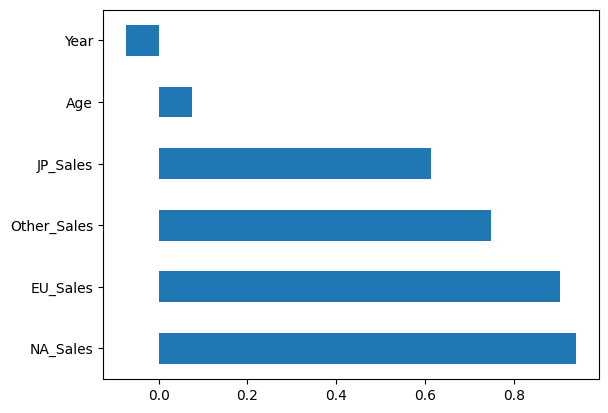

In [ ]:
# Визуализация корреляции
# ВАШ КОД ЗДЕСЬ
# correlation.drop('целевая_переменная').plot(kind='barh')
# plt.show()

correlation.drop('Global_Sales').plot(kind='barh')
plt.show()

In [ ]:
# Удаление слабых признаков (опционально)
# ВАШ КОД ЗДЕСЬ
# threshold = 0.1  # Порог корреляции
# weak_features = correlation[abs(correlation) < threshold].index.tolist()
# df = df.drop(columns=weak_features)

### Ваш анализ:

**Напишите здесь:**
- Какие признаки имеют самую сильную корреляцию с целевой переменной: Global sales, поскольку является собой.
- Какие признаки имеют слабую корреляцию: Publishers, Year
- Если не удалили, то почему оставили все: Все признаки имеют значимость

---

## Часть 5: Разделение на Train/Test

Разделите данные на обучающую и тестовую выборки.

In [ ]:
# Разделение на X и y
# ВАШ КОД ЗДЕСЬ
# X = df.drop('целевая_переменная', axis=1)
# y = df['целевая_переменная']

X = df.drop('Global_Sales', axis=1)
y = df['Global_Sales']

In [ ]:
# Train-Test Split
# ВАШ КОД ЗДЕСЬ
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
 )

In [ ]:
# Проверка размеров
# ВАШ КОД ЗДЕСЬ
# print(f"X_train: {X_train.shape}")
# print(f"X_test: {X_test.shape}")
# print(f"y_train: {y_train.shape}")
# print(f"y_test: {y_test.shape}")

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (13032, 46)
X_test: (3259, 46)
y_train: (13032,)
y_test: (3259,)


### Ваш анализ:

**Напишите здесь:**
- Сколько данных в train и test: train 13 032, test 2 359
- Какое соотношение использовали: 80/20
- Использовали ли stratify? Если да зачем: Нет, потому что это задача регрессии
- Почему важно разделять данные на train и test: для тренировки модели и оценки качества предсказания на новых данных

---

## Часть 6: Сохранение данных

Сохраните подготовленные данные.

In [ ]:
# Сохранение
# ВАШ КОД ЗДЕСЬ
# X_train.to_csv('X_train.csv', index=False)
# X_test.to_csv('X_test.csv', index=False)
# y_train.to_csv('y_train.csv', index=False)
# y_test.to_csv('y_test.csv', index=False)

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

---

## Часть 7: Итоговый вывод

Напишите резюме всей проделанной работы.

### Итоговое резюме:

**Напишите здесь полное резюме:**

**1. Что сделали с категориальными признаками:**
- Закодировала с помощью One-Hot Encoding

**2. Какое масштабирование применили:**
- StandardScaler к числовым колонкам

**3. Отбор признаков:**
- Сколько признаков было изначально: 9
- Сколько признаков осталось: 46
- Что удалили и почему: все признаки важны для обучения

**4. Разделение данных:**
- Train: 13 032 строк
- Test: 3 259 строк

**5. Готов ли датасет к ML? Что будете предсказывать?**
- Датасет готов к обучению, не имеет пропусков, данные разделены на train и тест и закодированы. Модель будет предсказывать Global_Sales